In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('charts', exist_ok=True)

BLUE   = '#2563EB'
PURPLE = '#7C3AED'
GREEN  = '#059669'
AMBER  = '#D97706'
RED    = '#DC2626'

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})
print("Setup done ✓")

Setup done ✓


In [2]:
df        = pd.read_csv('orders_clean_full.csv')
monthly   = pd.read_csv('monthly_trends.csv')
category  = pd.read_csv('category_performance.csv')
state     = pd.read_csv('state_performance.csv')
payments  = pd.read_csv('payment_analysis.csv')
delivery  = pd.read_csv('delivery_performance.csv')
rfm       = pd.read_csv('rfm_segments.csv')

# Fix types
df['gmv'] = pd.to_numeric(df['gmv'], errors='coerce')
df['delivery_delay_days'] = pd.to_numeric(df['delivery_delay_days'], errors='coerce')

print(f"orders_clean_full : {len(df):,} rows")
print(f"monthly_trends    : {len(monthly):,} rows")
print(f"category          : {len(category):,} rows")
print(f"state             : {len(state):,} rows")
print(f"payments          : {len(payments):,} rows")
print(f"delivery          : {len(delivery):,} rows")
print(f"rfm_segments      : {len(rfm):,} rows")
print(f"\nTotal GMV : R$ {df.gmv.sum():,.2f}")
print(f"Date range: {df.order_date.min()} → {df.order_date.max()}")

orders_clean_full : 99,441 rows
monthly_trends    : 25 rows
category          : 422 rows
state             : 27 rows
payments          : 7 rows
delivery          : 27 rows
rfm_segments      : 96,096 rows

Total GMV : R$ 15,843,553.24
Date range: 2016-09-04 → 2018-10-17


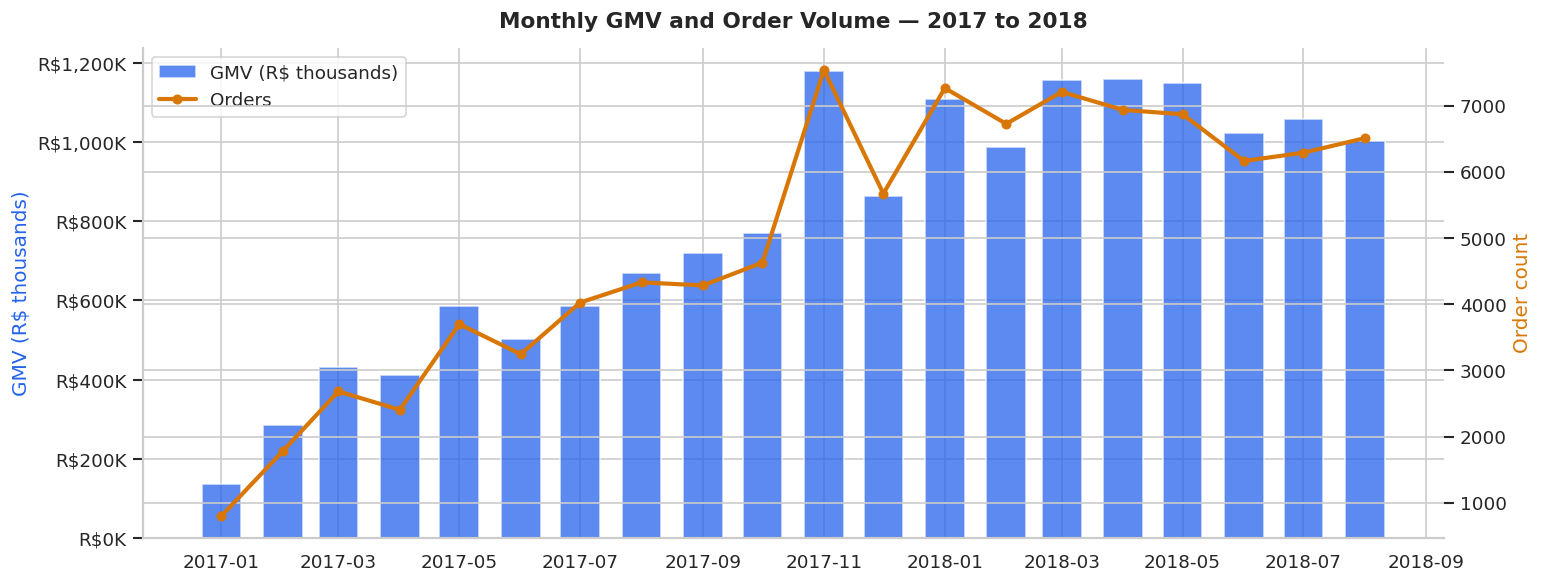

Peak month: Nov 2017 — R$1,179,144


In [4]:
# Filter 2017-2018 only, exclude incomplete months
monthly['order_year_month'] = pd.to_datetime(monthly['order_year_month'])
m = monthly[
    (monthly['order_year_month'] >= '2017-01-01') &
    (monthly['order_year_month'] <= '2018-08-31')
].sort_values('order_year_month')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(m.order_year_month, m.gmv/1e3, width=20,
        color=BLUE, alpha=0.75, label='GMV (R$ thousands)')
ax2.plot(m.order_year_month, m.orders,
         color=AMBER, lw=2.5, marker='o', ms=5, label='Orders')

ax1.set_ylabel('GMV (R$ thousands)', color=BLUE)
ax2.set_ylabel('Order count', color=AMBER)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}K'))
ax1.set_title('Monthly GMV and Order Volume — 2017 to 2018',
              fontsize=13, fontweight='bold', pad=12)

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='upper left')
plt.tight_layout()
plt.savefig('charts/01_monthly_gmv.png', dpi=150, bbox_inches='tight')
plt.show()

peak = m.loc[m.gmv.idxmax()]
print(f"Peak month: {peak['order_year_month'].strftime('%b %Y')} — R${peak['gmv']:,.0f}")

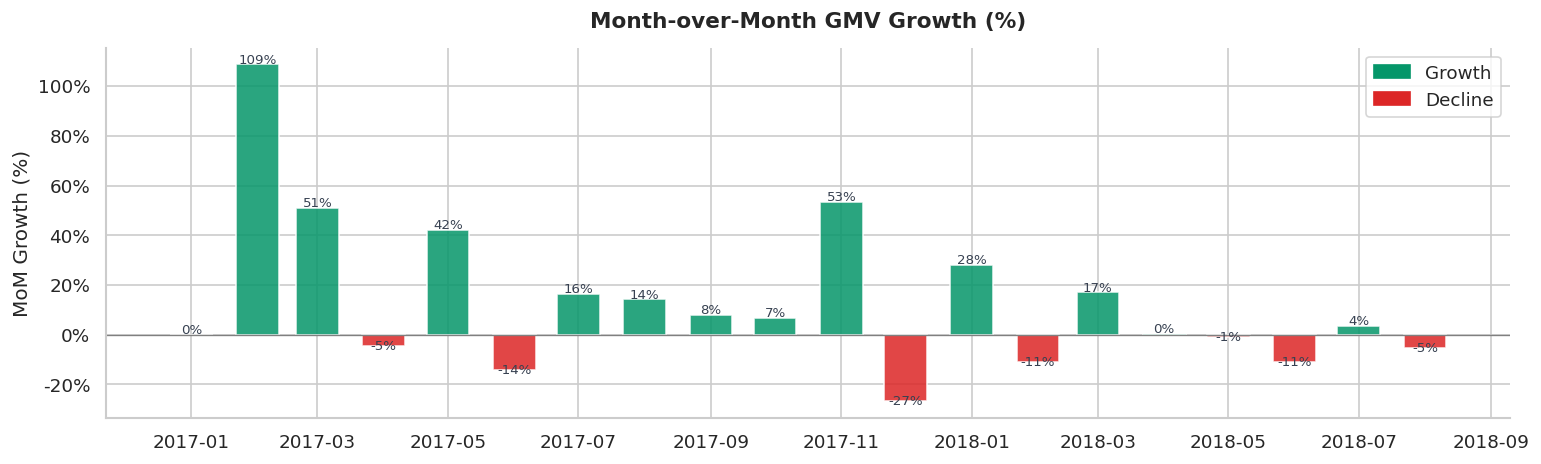

Months with growth: 12
Months with decline: 7


In [5]:
m = m.sort_values('order_year_month').copy()
m['mom_pct'] = m['gmv'].pct_change() * 100

fig, ax = plt.subplots(figsize=(13, 4))
colors = [GREEN if v >= 0 else RED for v in m.mom_pct.fillna(0)]
bars = ax.bar(m.order_year_month, m.mom_pct.fillna(0),
              width=20, color=colors, alpha=0.85)

# Add value labels on each bar
for bar, val in zip(bars, m.mom_pct.fillna(0)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.5 if val >= 0 else -1.5),
            f'{val:.0f}%', ha='center', fontsize=8,
            color='#374151')

ax.axhline(0, color='gray', lw=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.set_ylabel('MoM Growth (%)')
ax.set_title('Month-over-Month GMV Growth (%)',
             fontsize=13, fontweight='bold', pad=12)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=GREEN, label='Growth'),
    Patch(color=RED, label='Decline')
], loc='upper right')

plt.tight_layout()
plt.savefig('charts/02_mom_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Months with growth: {(m.mom_pct > 0).sum()}")
print(f"Months with decline: {(m.mom_pct < 0).sum()}")

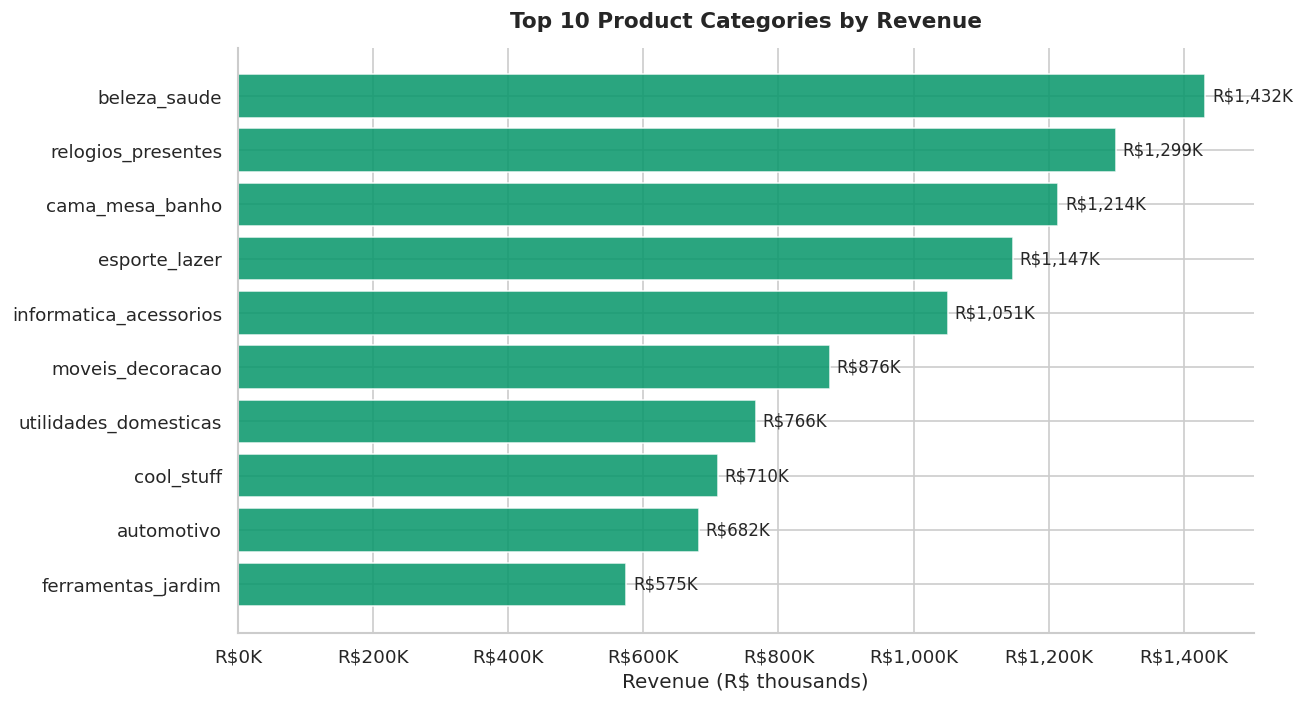

Top 5 categories = 38.8% of total revenue
#1 category: beleza_saude — R$1,431,563


In [6]:
# Take top 10 by revenue only
cat = category.nlargest(10, 'revenue').sort_values('revenue', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(cat['category_name'], cat['revenue']/1e3,
               color=GREEN, alpha=0.85)
ax.bar_label(bars, labels=[f'R${v/1e3:,.0f}K' for v in cat['revenue']],
             padding=4, fontsize=10)
ax.set_xlabel('Revenue (R$ thousands)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}K'))
ax.set_title('Top 10 Product Categories by Revenue',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('charts/03_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

# Pareto insight
total_rev = category['revenue'].sum()
top5_share = category.nlargest(5, 'revenue')['revenue'].sum() / total_rev * 100
print(f"Top 5 categories = {top5_share:.1f}% of total revenue")
print(f"#1 category: {cat.iloc[-1]['category_name']} — R${cat.iloc[-1]['revenue']:,.0f}")

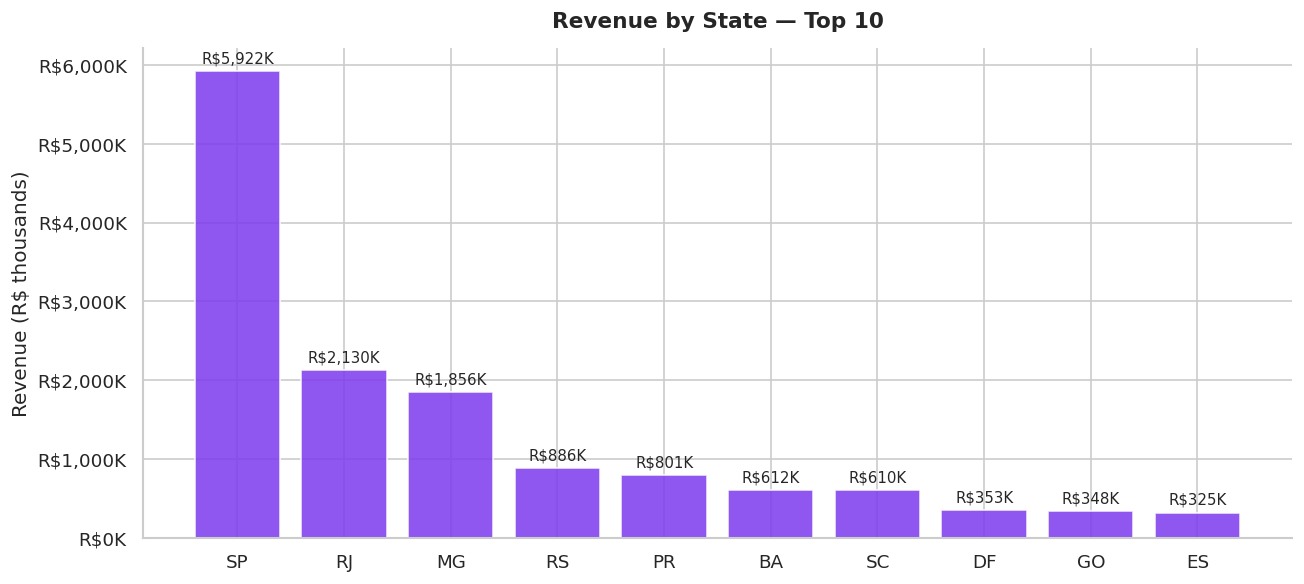

SP share: 37.4% of total GMV
SP + RJ + MG: 62.5% of GMV


In [7]:
# Top 10 states by revenue
st = state.nlargest(10, 'revenue').sort_values('revenue', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(st['customer_state'], st['revenue']/1e3,
              color=PURPLE, alpha=0.85)
ax.bar_label(bars, labels=[f'R${v/1e3:,.0f}K' for v in st['revenue']],
             padding=3, fontsize=9)
ax.set_ylabel('Revenue (R$ thousands)')
ax.set_title('Revenue by State — Top 10',
             fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}K'))
plt.tight_layout()
plt.savefig('charts/04_revenue_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

sp = st[st['customer_state']=='SP']['revenue'].values[0]
total = state['revenue'].sum()
print(f"SP share: {sp/total*100:.1f}% of total GMV")
print(f"SP + RJ + MG: {state[state['customer_state'].isin(['SP','RJ','MG'])]['revenue'].sum()/total*100:.1f}% of GMV")

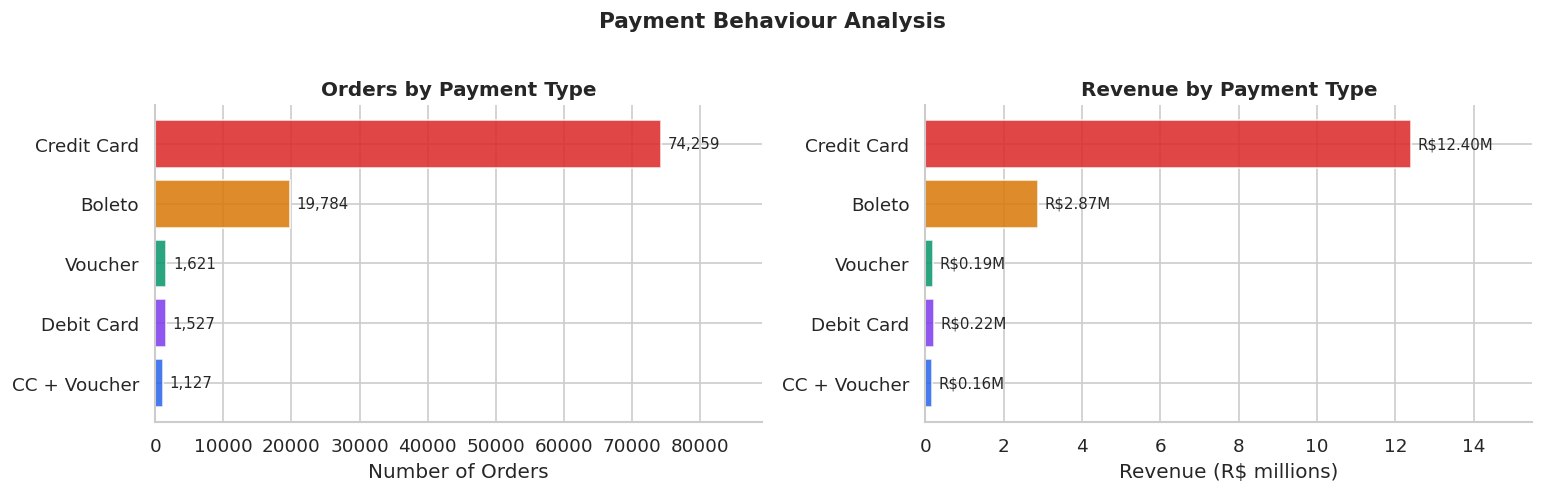

Credit card order share: 75.5%
Credit card AOV: R$166.95
Boleto AOV:      R$145.03


In [9]:
payments['payment_types'] = payments['payment_types'].replace({
    'credit_card': 'Credit Card',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Debit Card',
    'credit_card,voucher': 'CC + Voucher',
    'voucher,credit_card': 'CC + Voucher',
})

# Keep top 5 only — removes clutter
pay = payments.nlargest(5, 'orders').sort_values('orders', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors5 = [BLUE, PURPLE, GREEN, AMBER, RED]

# Chart 1 — Orders
bars = axes[0].barh(pay['payment_types'], pay['orders'],
                    color=colors5, alpha=0.85)
axes[0].bar_label(bars, labels=[f'{v:,}' for v in pay['orders']],
                  padding=4, fontsize=9)
axes[0].set_xlabel('Number of Orders')
axes[0].set_title('Orders by Payment Type', fontweight='bold')
axes[0].set_xlim(0, pay['orders'].max() * 1.2)  # extra space for labels

# Chart 2 — Revenue in M not K
bars2 = axes[1].barh(pay['payment_types'], pay['revenue']/1e6,
                     color=colors5, alpha=0.85)
axes[1].bar_label(bars2,
    labels=[f'R${v/1e6:,.2f}M' for v in pay['revenue']],   # M not K
    padding=4, fontsize=9)
axes[1].set_xlabel('Revenue (R$ millions)')
axes[1].set_title('Revenue by Payment Type', fontweight='bold')
axes[1].set_xlim(0, pay['revenue'].max()/1e6 * 1.25)  # extra space for labels

fig.suptitle('Payment Behaviour Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/05_payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

cc     = pay[pay['payment_types']=='Credit Card']
boleto = pay[pay['payment_types']=='Boleto']
print(f"Credit card order share: {cc['orders'].values[0]/pay['orders'].sum()*100:.1f}%")
print(f"Credit card AOV: R${cc['avg_order_value'].values[0]:,.2f}")
print(f"Boleto AOV:      R${boleto['avg_order_value'].values[0]:,.2f}")

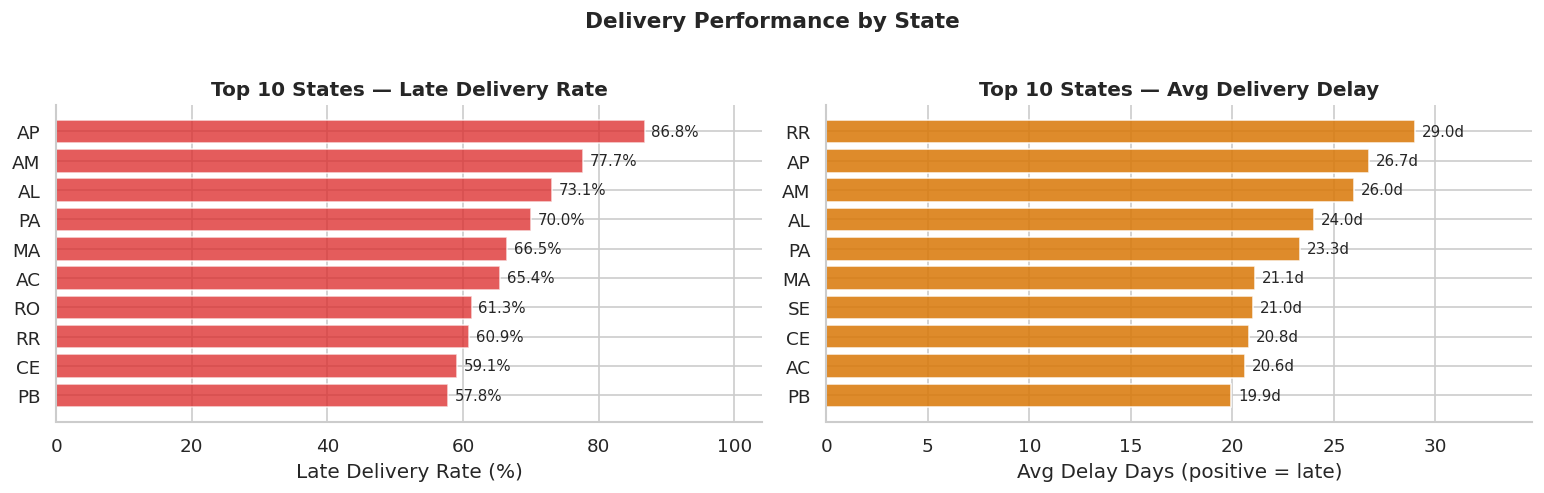

Overall on-time / early: 76.7%
Overall late rate:       23.3%
Worst state: AP — 86.8% late
Best state:  SP — 9.3% late


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Chart 1 — Late rate by state (top 10 worst)
del_state = delivery.nlargest(10, 'late_pct').sort_values('late_pct', ascending=True)

bars = axes[0].barh(del_state['customer_state'], del_state['late_pct'],
                    color=RED, alpha=0.75)
axes[0].bar_label(bars, labels=[f'{v:.1f}%' for v in del_state['late_pct']],
                  padding=4, fontsize=9)
axes[0].set_xlabel('Late Delivery Rate (%)')
axes[0].set_title('Top 10 States — Late Delivery Rate',
                  fontweight='bold')
axes[0].set_xlim(0, del_state['late_pct'].max() * 1.2)

# Chart 2 — Avg delay days by state (top 10 worst)
del_delay = delivery.nlargest(10, 'avg_delay_days').sort_values(
    'avg_delay_days', ascending=True)

bars2 = axes[1].barh(del_delay['customer_state'], del_delay['avg_delay_days'],
                     color=AMBER, alpha=0.85)
axes[1].bar_label(bars2,
    labels=[f'{v:.1f}d' for v in del_delay['avg_delay_days']],
    padding=4, fontsize=9)
axes[1].set_xlabel('Avg Delay Days (positive = late)')
axes[1].set_title('Top 10 States — Avg Delivery Delay',
                  fontweight='bold')
axes[1].set_xlim(0, del_delay['avg_delay_days'].max() * 1.2)

fig.suptitle('Delivery Performance by State',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/06_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

overall_late = delivery['late_orders'].sum() / delivery['total_orders'].sum() * 100
overall_early = 100 - overall_late
print(f"Overall on-time / early: {overall_early:.1f}%")
print(f"Overall late rate:       {overall_late:.1f}%")
worst = delivery.nlargest(1, 'late_pct')
best  = delivery.nsmallest(1, 'late_pct')
print(f"Worst state: {worst['customer_state'].values[0]} — {worst['late_pct'].values[0]:.1f}% late")
print(f"Best state:  {best['customer_state'].values[0]} — {best['late_pct'].values[0]:.1f}% late")

In [12]:
print(rfm.columns.tolist())
print(rfm.head(2))

['customer_unique_id', 'recency_days', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_total', 'customer_segment']
                 customer_unique_id  recency_days  frequency  monetary  \
0  b7d76e111c89f7ebf14761390f0f7d17           773          1    136.23   
1  4854e9b3feff728c13ee5fc7d1547e92           772          1     75.06   

   r_score  f_score  m_score  rfm_total  customer_segment  
0        1        2        2          5              Lost  
1        1        3        3          7  Cannot Lose Them  


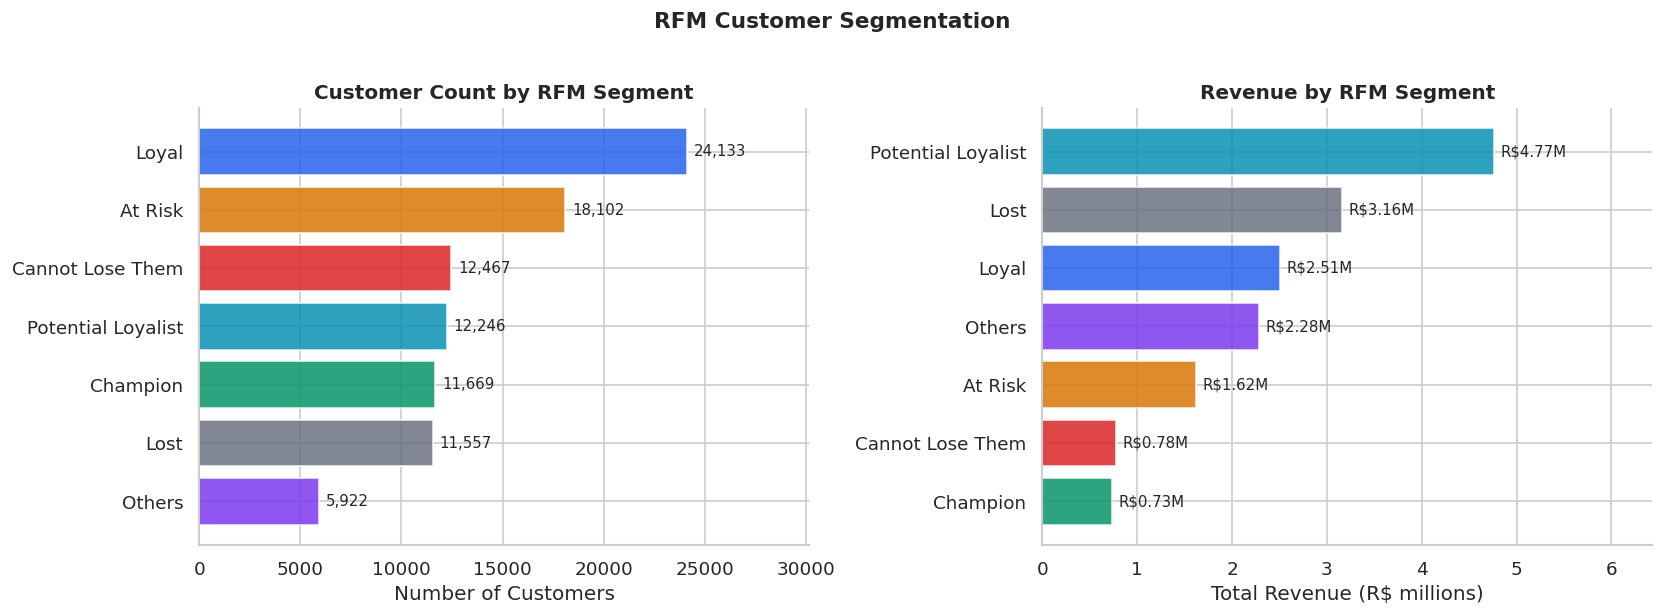

By customer count:
  customer_segment  customers
             Loyal      24133
           At Risk      18102
  Cannot Lose Them      12467
Potential Loyalist      12246
          Champion      11669
              Lost      11557
            Others       5922

By revenue:
  customer_segment  total_rev
Potential Loyalist 4765203.39
              Lost 3158282.30
             Loyal 2507943.85
            Others 2280229.00
           At Risk 1623645.11
  Cannot Lose Them  776776.74
          Champion  731472.85


In [16]:
seg = rfm.groupby('customer_segment').agg(
    customers  = ('customer_unique_id', 'count'),
    avg_spend  = ('monetary', 'mean'),
    total_rev  = ('monetary', 'sum'),
    avg_recency= ('recency_days', 'mean')
).reset_index()

seg_colors_map = {
    'Champion':          '#059669',
    'Loyal':             '#2563EB',
    'Potential Loyalist':'#0891B2',
    'At Risk':           '#D97706',
    'Cannot Lose Them':  '#DC2626',
    'Lost':              '#6B7280',
    'Others':            '#7C3AED'
}

# Two separate sorts
seg_by_count = seg.sort_values('customers', ascending=True)
seg_by_rev   = seg.sort_values('total_rev', ascending=True)

colors_count = [seg_colors_map.get(s, BLUE) for s in seg_by_count.customer_segment]
colors_rev   = [seg_colors_map.get(s, BLUE) for s in seg_by_rev.customer_segment]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — sorted by customer count
bars = axes[0].barh(seg_by_count.customer_segment, seg_by_count.customers,
                    color=colors_count, alpha=0.85)
axes[0].bar_label(bars,
    labels=[f'{v:,}' for v in seg_by_count.customers],
    padding=4, fontsize=9)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count by RFM Segment', fontweight='bold')
axes[0].set_xlim(0, seg_by_count.customers.max() * 1.25)

# Chart 2 — sorted by revenue
bars2 = axes[1].barh(seg_by_rev.customer_segment, seg_by_rev.total_rev/1e6,
                     color=colors_rev, alpha=0.85)
axes[1].bar_label(bars2,
    labels=[f'R${v/1e6:,.2f}M' for v in seg_by_rev.total_rev],
    padding=4, fontsize=9)
axes[1].set_xlabel('Total Revenue (R$ millions)')
axes[1].set_title('Revenue by RFM Segment', fontweight='bold')
axes[1].set_xlim(0, seg_by_rev.total_rev.max()/1e6 * 1.35)

fig.suptitle('RFM Customer Segmentation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/07_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("By customer count:")
print(seg.sort_values('customers', ascending=False)[
    ['customer_segment','customers']].to_string(index=False))
print("\nBy revenue:")
print(seg.sort_values('total_rev', ascending=False)[
    ['customer_segment','total_rev']].to_string(index=False))

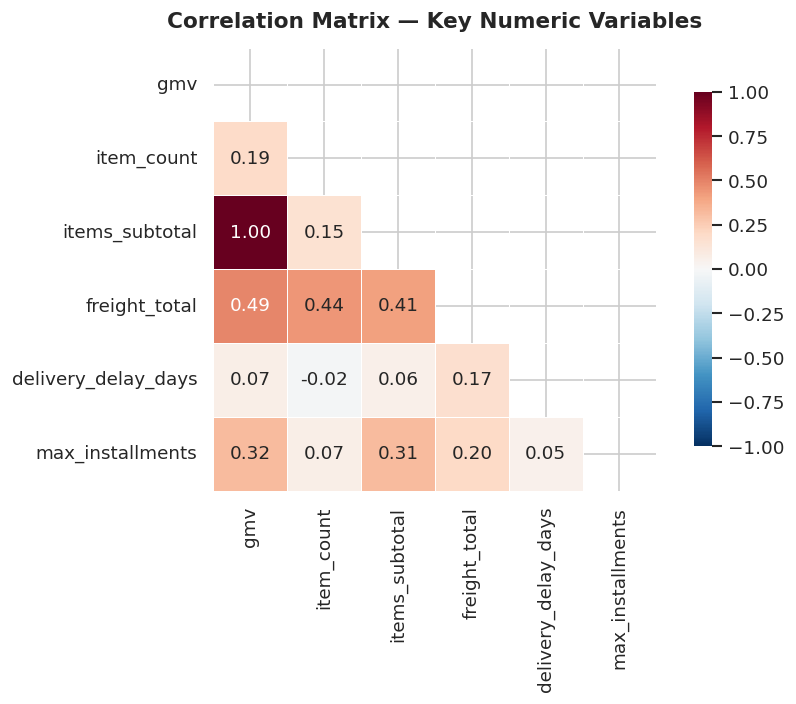

Strong correlations (>0.5):
var1           var2  correlation
 gmv items_subtotal     0.995958


In [17]:
# Select numeric columns from main df
num_cols = df[['gmv','item_count','items_subtotal',
               'freight_total','delivery_delay_days',
               'max_installments']].apply(
    pd.to_numeric, errors='coerce').dropna()

corr = num_cols.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Numeric Variables',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('charts/08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Strong correlations (>0.5):")
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['var1','var2','correlation']
corr_pairs = corr_pairs[
    (corr_pairs.var1 != corr_pairs.var2) &
    (corr_pairs.correlation.abs() > 0.5) &
    (corr_pairs.var1 < corr_pairs.var2)
].sort_values('correlation', ascending=False)
print(corr_pairs.to_string(index=False))